<a href="https://colab.research.google.com/github/dchappell2/Analytical_Mechanics/blob/main/HonorsAI/llm_exploration_lab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 LLM Exploration Lab
### How do language models actually decide what word comes next?

In this lab you will:
- See how text is broken into **tokens** (the model's basic unit of input)
- Inspect the **probability distribution** a model produces for the next token
- Experiment with **temperature** and sampling strategies
- Explore how **prompt phrasing** shifts predictions
- Explore **embedding spaces** and do vector arithmetic (king − man + woman = queen)
- Write your own **custom sampling loop** (bonus section)

**Model used:** GPT-2 (small, 124M parameters) — runs on CPU in seconds, no GPU needed.  
**Libraries:** `transformers`, `tiktoken`, `matplotlib`, `ipywidgets`, `numpy`

---
> 💡 **Run cells in order.** Each section builds on the previous one.

## ⚙️ Setup — install and import everything

In [ ]:
# Run once — takes about 30 seconds
!pip install -q transformers tiktoken matplotlib ipywidgets torch gensim scikit-learn --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import tiktoken
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Load model and tokenizer
print('Loading GPT-2... (first run downloads ~500 MB)')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()
print('✅ Ready!')

Loading GPT-2... (first run downloads ~500 MB)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Ready!


---
## Section 1 · Tokenization
### How does the model read text?

Language models don't read words — they read **tokens**. A token is roughly a word or a word-piece (common prefixes, suffixes, or subword fragments). Each token maps to an integer ID that the model uses internally. Tokens are chosen based on how frequently a word or string of letters and numbers appear in the training data. ChatGPT-2 uses about 50,000 tokens.

**Key intuitions to build:**
- Common words → single token (e.g. `" the"` = token 262)
- Rare words → multiple tokens (e.g. `"Supercalifragilistic"` = 4 tokens)
- Spaces and punctuation are part of tokens — `" dog"` ≠ `"dog"`

Run the following Code Cell:

In [ ]:
# ── Explore tokenization ──────────────────────────────────────────────
def show_tokens(text, tokenizer):
    """Print token IDs and their string representations side by side."""
    token_ids = tokenizer.encode(text)
    tokens    = [tokenizer.decode([t]) for t in token_ids]

    print(f'Input text : "{text}"')
    print(f'Token count: {len(token_ids)}\n')
    print(f'{"Index":>6}  {"Token ID":>9}  {"String"}')
    print('-' * 40)
    for i, (tid, tok) in enumerate(zip(token_ids, tokens)):
        print(f'{i:>6}  {tid:>9}  {repr(tok)}')

# Try it on a few examples
show_tokens('The quick brown fox jumps over the lazy dog.', tokenizer)

Input text : "The quick brown fox jumps over the lazy dog."
Token count: 10

 Index   Token ID  String
----------------------------------------
     0        464  'The'
     1       2068  ' quick'
     2       7586  ' brown'
     3      21831  ' fox'
     4      18045  ' jumps'
     5        625  ' over'
     6        262  ' the'
     7      16931  ' lazy'
     8       3290  ' dog'
     9         13  '.'


Notice that each word corresponds to a single token.

**Question 1a**

Type in your own text in the following example replacing "Your text here". Try to find a simple sentence where each word is a single token. Copy your sentence and the output to the lab document provided.

In [ ]:
show_tokens('your text here', tokenizer)

**Question 1b**

Now try to find a sentence where many or most of the words are represented by multiple tokens. Copy your sentence and the output to the lab document provided.


In [ ]:
show_tokens('your text here', tokenizer)

**Question 1c**

Now use your name to see how it is tokenized.  Copy your name and the output to the lab document provided. How many tokens does your name take?

In [ ]:
show_tokens('your text here', tokenizer)

**Question 1d**

Try a list of numbers. Give examples of numbers that are represented by a single token. Why do you think ChatGPT-2 uses a single token for these numbers? Give examples of numbers that use multiple tokens.


In [ ]:
show_tokens('your text here', tokenizer)

Run the following Code Cell. It will display the size of the chatGPT-2 vocabulary (i.e. the number of tokens used), which is over 50,000 tokens. It also shows a random sample of tokens that it uses. Re-run the code cell several times to see more token examples.

**Question 2a**

List five examples of tokens that you might expect, i.e. tokens that correspond to commonly used words.

**Question 2b**

List five examples of tokens that you find surprising, i.e. uncommon words, letters or numbers. Why do you think chatGPT-2 chose these as tokens?


In [ ]:
# ── 🧪 Experiment 1-B: Vocabulary size and a random sample ───────────
vocab_size = tokenizer.vocab_size
print(f'GPT-2 vocabulary size: {vocab_size:,} tokens\n')

# Show 20 random tokens from different parts of the vocabulary
print('Sample tokens from the vocabulary:')
for tid in sorted(np.random.choice(vocab_size, 20, replace=False)):
    print(f'  ID {tid:>6}: {repr(tokenizer.decode([tid]))}')

GPT-2 vocabulary size: 50,257 tokens

Sample tokens from the vocabulary:
  ID   1188: ' val'
  ID   2892: ' Mon'
  ID   4724: ' guess'
  ID   5759: ' stret'
  ID   7557: ' Fund'
  ID  10048: ' 94'
  ID  16884: ' Wizard'
  ID  18980: ' Format'
  ID  23268: ' vow'
  ID  25281: ' jurisdictions'
  ID  26019: ' calculating'
  ID  29596: ' therapies'
  ID  38771: ' queens'
  ID  39975: 'ourses'
  ID  42379: ' Nguyen'
  ID  43537: ' Spice'
  ID  46875: ' spirited'
  ID  48036: ' locality'
  ID  48463: ' Faces'
  ID  48999: ']}'


---
## Section 2 · Next-Token Probabilities
### What does the model predict?

Given a prompt, the model produces a probability for **every** token in the vocabulary.  We can inspect this distribution to see what the model "thinks" comes next.

Run the following code to predict the next word given the prompt "The capital of France is". This code cell has some complicated code. But the actual command is at the very bottom:  `next_word('The capital of France is')`

Prompt: "The capital of France is"

Rank            Token   Probability
--------------------------------------
   1           ' the'        8.46%
   2           ' now'        4.79%
   3             ' a'        4.62%
   4        ' France'        3.24%
   5         ' Paris'        3.22%
   6            ' in'        2.66%
   7          ' also'        2.64%
   8           ' not'        2.38%
   9          ' home'        2.33%
  10         ' still'        1.55%
  11         ' under'        1.42%
  12       ' located'        1.39%
  13            ' on'        1.34%
  14           ' one'        1.13%
  15         ' known'        0.94%

Entropy of distribution: 5.998 nats
Sum of top-15 probabilities: 42.1%


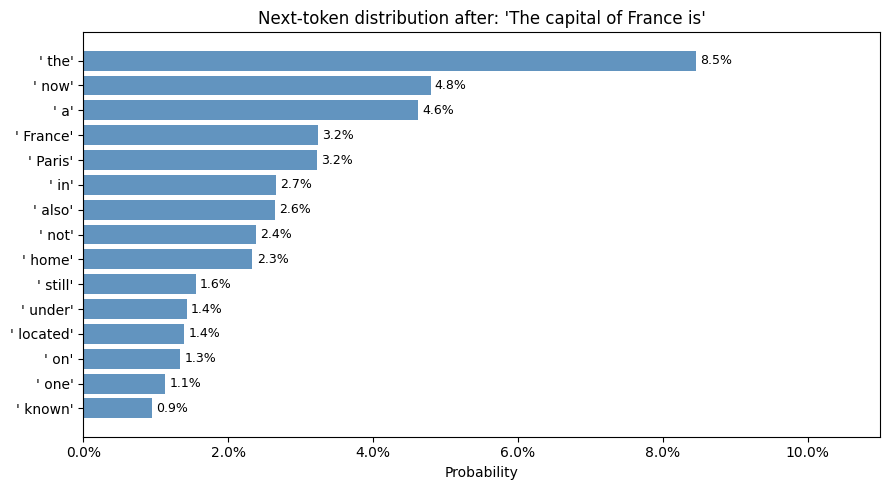

In [ ]:
# ── Core helper: get next-token probability distribution ──────────────
def get_next_token_probs(prompt, model, tokenizer, top_k=20):
    """
    Returns:
      probs       - full softmax distribution over vocab (numpy array)
      top_tokens  - list of (token_string, probability) for top_k tokens
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    with torch.no_grad():
        outputs = model(input_ids)
    logits = outputs.logits[0, -1, :]          # last-position logits
    probs  = F.softmax(logits, dim=-1).numpy()

    top_indices = np.argsort(probs)[::-1][:top_k]
    top_tokens  = [(tokenizer.decode([i]), float(probs[i])) for i in top_indices]
    return probs, top_tokens


def plot_top_tokens(top_tokens, prompt, ax=None, color='steelblue'):
    """Bar chart of top-k next-token probabilities."""
    labels = [repr(t) for t, _ in top_tokens]
    values = [p          for _, p in top_tokens]

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4))

    bars = ax.barh(labels[::-1], values[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Probability')
    ax.set_title(f'Next-token distribution after: {repr(prompt[-40:])}')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.bar_label(bars, [f'{v:.1%}' for v in values[::-1]], padding=3, fontsize=9)
    ax.set_xlim(0, max(values) * 1.3)
    plt.tight_layout()
    return ax

def next_word(prompt):
    probs, top = get_next_token_probs(prompt, model, tokenizer, top_k=15)

    print(f'Prompt: "{prompt}"\n')
    print(f'{"Rank":>4}  {"Token":>15}  {"Probability":>12}')
    print('-' * 38)
    for rank, (tok, p) in enumerate(top, 1):
        print(f'{rank:>4}  {repr(tok):>15}  {p:>11.2%}')
    print(f'\nEntropy of distribution: {-np.sum(probs * np.log(probs + 1e-12)):.3f} nats')
    print(f'Sum of top-{len(top)} probabilities: {sum(p for _,p in top):.1%}')
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_top_tokens(top, prompt, ax=ax)
    plt.show()


next_word('The capital of France is')


Notice the following:
* The code produces a table of the most likely next words and a graph showing the same information.
* 'Paris' is **not** the most likely next word. In fact, it only has a 3.22% probability of being the next word.
* The most likely next word is 'the' at 8.5%
* The message after the table shows the these top 15 tokens would only be chosen 42.1% of the time. This means that most of the time (58.9%), a word not on this list would be chosen.
* The message also gives the 'entropy' of the prediction. The entropy is higher when the model is not sure what to choose for the next word if the top choice is not picked.


Here's another example. Since we've defined the Python functions, we can now just use the following simple command. Replace 'your text here' with the following prompt:  'Once upon a time there was a'. Run the code cell:

Prompt: "Once upon a time there was a"

Rank            Token   Probability
--------------------------------------
   1         ' great'        4.04%
   2           ' man'        3.92%
   3           ' war'        1.19%
   4         ' woman'        1.11%
   5       ' certain'        1.11%
   6         ' small'        0.89%
   7         ' large'        0.88%
   8           ' lot'        0.76%
   9          ' time'        0.73%
  10          ' very'        0.72%
  11         ' place'        0.59%
  12           ' new'        0.54%
  13          ' good'        0.44%
  14          ' fire'        0.42%
  15         ' young'        0.42%

Entropy of distribution: 7.584 nats
Sum of top-15 probabilities: 17.8%


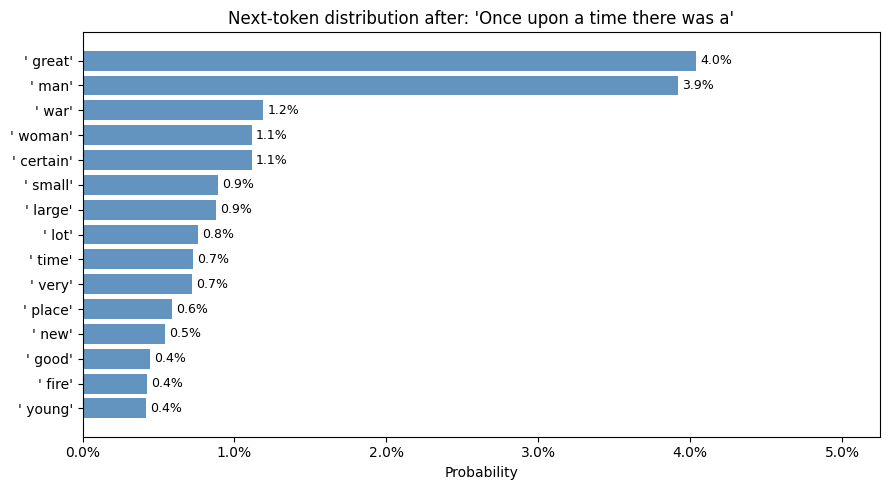

In [ ]:
next_word('your text here')


Let's try on more. Type the following math equation in and run:  '1 + 1 = '.

In [ ]:
next_word('your text here')


**Question 3a**

Come up with your own prompts and see what the next word prediction is. When you find an interesting result, copy the table of word/token probabilities to the Response Document.


Prompt: "1 + 1 ="

Rank            Token   Probability
--------------------------------------
   1             ' 1'       13.64%
   2             ' 0'       10.88%
   3             ' 2'        7.57%
   4             ' 3'        3.65%
   5             ' -'        2.55%
   6             ' 4'        2.45%
   7             ' 5'        2.21%
   8             ' +'        1.85%
   9             ' ('        1.82%
  10            ' 10'        1.67%
  11             ' $'        1.58%
  12             ' 6'        1.35%
  13             ' 8'        0.97%
  14            ' 12'        0.82%
  15             ' 7'        0.79%

Entropy of distribution: 5.393 nats
Sum of top-15 probabilities: 53.8%


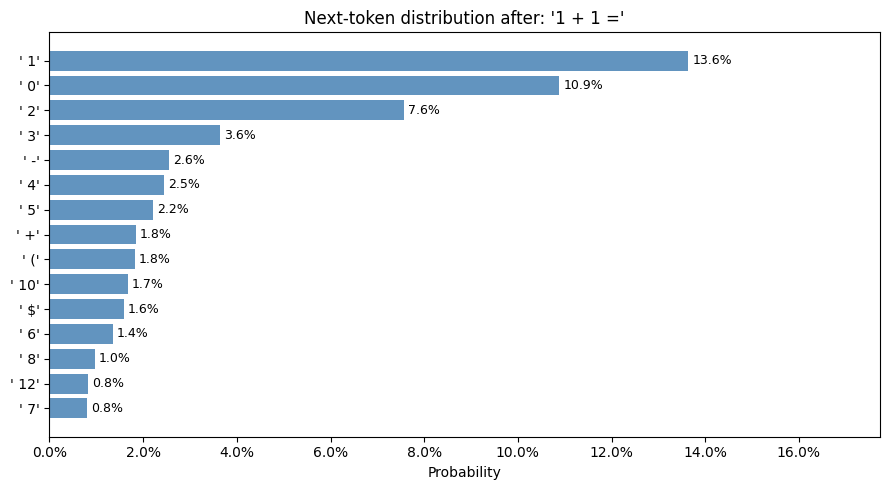

In [ ]:
next_word('your text here')

**Question 3b**
Reflect on the word distributions (the three examples in the Google Colab document and your example). What do you notice?  Which words/numbers are what you expected? Which are surprising? Do you notice any biases or other unusual patterns in the distributions? Which prompts are the most peaked, with the highest probability for the first choice?Which has the highest entropy?  Why do you think that is?



---
## Section 3 · Temperature and Sampling Strategies
### How does the model choose one token from the distribution?

The model outputs a distribution — but it must **pick one token** to generate. The strategy used dramatically changes the output:

| Strategy | Description |
|---|---|
| **Greedy** | Always pick the highest-probability token |
| **Temperature sampling** | Divide logits by `T` before softmax. `T<1` sharpens; `T>1` flattens |
| **Top-k sampling** | Sample from only the `k` most likely tokens |
| **Top-p (nucleus) sampling** | Sample from the smallest set of tokens whose cumulative prob ≥ `p` |

**Temperature** is the most important knob:
```
T → 0   : greedy (always pick the peak)
T = 1   : standard sampling (use the distribution as-is)
T > 1   : more random / creative / chaotic
T → ∞   : uniform random (all tokens equally likely)
```

The following code predicts the next word in the prompt "Once upon a time there was a". It shows how likely the different outcomes are for 4 different temperatures:  0.01, 0.5, 1.0 and 10.0. The lower the temperature, the more likely the system will pick the token with the highest probability. As the temperature increases, the word choice becomes more random with other words appearing.

Run the following Code Cell:

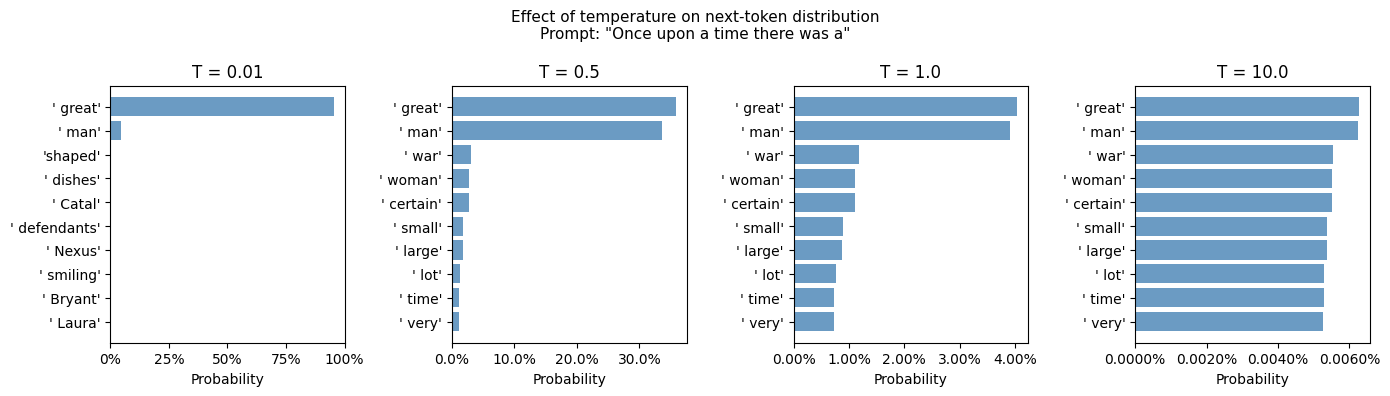


Notice: low T → peaked (confident), high T → flat (uncertain)


In [ ]:
# ── Sampling helpers ──────────────────────────────────────────────────
def apply_temperature(logits, temperature):
    """Scale logits by temperature, then softmax."""
    if temperature <= 0:
        temperature = 1e-9  # near-zero = greedy
    scaled = logits / temperature
    return F.softmax(scaled, dim=-1)


def apply_top_k(probs, k):
    """Zero out all tokens outside the top-k, then renormalise."""
    top_k_probs, top_k_idx = torch.topk(probs, k)
    filtered = torch.zeros_like(probs)
    filtered.scatter_(0, top_k_idx, top_k_probs)
    return filtered / filtered.sum()


def apply_top_p(probs, p):
    """Nucleus sampling: keep only the smallest set summing to >= p."""
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=0)
    # Remove tokens once cumulative prob exceeds p (keep at least one)
    remove_mask = (cumulative - sorted_probs) >= p
    sorted_probs[remove_mask] = 0.0
    filtered = torch.zeros_like(probs)
    filtered.scatter_(0, sorted_idx, sorted_probs)
    return filtered / filtered.sum()


def generate_tokens(prompt, model, tokenizer, max_new=20,
                    temperature=1.0, top_k=None, top_p=None):
    """Generate up to max_new tokens using the specified strategy."""
    input_ids = tokenizer.encode(prompt, return_tensors='pt')

    with torch.no_grad():
        for _ in range(max_new):
            outputs = model(input_ids)
            logits  = outputs.logits[0, -1, :]
            probs   = apply_temperature(logits, temperature)

            if top_k is not None:
                probs = apply_top_k(probs, top_k)
            if top_p is not None:
                probs = apply_top_p(probs, top_p)

            next_token = torch.multinomial(probs, num_samples=1)
            input_ids  = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)

            # Stop at end-of-text
            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(input_ids[0], skip_special_tokens=True)

# ── Visualise how temperature reshapes the distribution ───────────────
def temperature_example(prompt):
    input_ids = tokenizer.encode(prompt, return_tensors='pt')

    with torch.no_grad():
        outputs = model(input_ids)
    logits = outputs.logits[0, -1, :]

    temperatures = [0.01, 0.5, 1.0, 10.0]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

    for ax, T in zip(axes, temperatures):
        probs = apply_temperature(logits, T).numpy()
        top_idx = np.argsort(probs)[::-1][:10]
        top_p_vals = probs[top_idx]
        top_labels = [repr(tokenizer.decode([i])) for i in top_idx]

        ax.barh(top_labels[::-1], top_p_vals[::-1], color='steelblue', alpha=0.8)
        ax.set_title(f'T = {T}', fontsize=12)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_xlabel('Probability')

    plt.suptitle(f'Effect of temperature on next-token distribution\nPrompt: "{prompt}"',
             fontsize=11)
    plt.tight_layout()
    plt.show()
    print('\nNotice: low T → peaked (confident), high T → flat (uncertain)')

temperature_example('Once upon a time there was a')

Try running this command with your own prompt to see how temperature affects the word probabilities:

In [ ]:
temperature_example('your code here')

Let's now see how temperature can affect the sentences. The following code creates an interactive interface where you can type in a prompt. The sliders control the following
* Temperature - discussed above. Low temperatures mean the word with the highest probability is (almost) always chosen. High temperatures mean the word choice is more random.
* Top-k - This controls the how many words (tokens) to choose from. For example, if Top-k = 5, only the next word is only chosen from the top 5 most likely words.
* Top-p - If, for example Top-p = 0.1, only the top 0.1 (or 10%) of the words are used to sample from.
* Max Tokens - Length of the response (in tokens).
* number of runs - How many examples to generate for each when you click "Generate"

Run the following Code Cell, scroll down to the bottom to see the input and sliders, and try it for your own prompt:

In [ ]:
# ── 🎛️ Interactive widget: tune temperature and sampling ─────────────
prompt_widget = widgets.Text(
    value='Artificial intelligence will',
    description='Prompt:',
    layout=widgets.Layout(width='60%')
)
temp_widget = widgets.FloatSlider(
    value=1.0, min=0.05, max=2.5, step=0.05,
    description='Temperature:', style={'description_width': '110px'},
    layout=widgets.Layout(width='50%')
)
topk_widget = widgets.IntSlider(
    value=0, min=0, max=100, step=1,
    description='Top-k (0=off):', style={'description_width': '110px'},
    layout=widgets.Layout(width='50%')
)
topp_widget = widgets.FloatSlider(
    value=0.0, min=0.0, max=1.0, step=0.01,
    description='Top-p (0=off):', style={'description_width': '110px'},
    layout=widgets.Layout(width='50%')
)
max_tokens_widget = widgets.IntSlider(
    value=20, min=5, max=60, step=5,
    description='Max tokens:', style={'description_width': '110px'},
    layout=widgets.Layout(width='50%')
)
runs_widget = widgets.IntSlider(
    value=3, min=1, max=8, step=1,
    description='# runs:', style={'description_width': '110px'},
    layout=widgets.Layout(width='40%')
)
button = widgets.Button(
    description='▶ Generate',
    button_style='primary',
    layout=widgets.Layout(width='150px', height='36px')
)
output = widgets.Output()

def on_generate(b):
    with output:
        clear_output(wait=True)
        T    = temp_widget.value
        k    = topk_widget.value  or None
        p    = topp_widget.value  or None
        n    = max_tokens_widget.value
        runs = runs_widget.value
        pr   = prompt_widget.value

        print(f'Prompt: "{pr}"')
        print(f'Settings: T={T}, top_k={k}, top_p={p}, max_tokens={n}\n')
        for i in range(runs):
            result = generate_tokens(pr, model, tokenizer,
                                     max_new=n, temperature=T, top_k=k, top_p=p)
            print(f'Run {i+1}: {result}\n')

button.on_click(on_generate)

display(
    widgets.VBox([
        prompt_widget,
        temp_widget,
        topk_widget,
        topp_widget,
        max_tokens_widget,
        runs_widget,
        button,
        output
    ])
)

**Question 4**

Try different prompts and different parameter values.
* How does adjusting the parameters affect the output?  
* What do you notice? Which parameter settings give the most natural, human-like responses?

Give examples of the prompts, parameter values and output to illustrate your responses.

Also in crafting your response, consider the following questions:
* With T≈0, does running it multiple times give the same output? Why?
* At T=2, is the output still grammatical? Coherent?

---
## Section 4 · Embedding Spaces
### How does the model "understand" meaning?

Before a model processes text, every token is converted into a **vector** — a list of ~768 numbers (for GPT-2 base). These vectors live in a high-dimensional space where **geometry encodes meaning**:

- Similar words cluster together
- Relationships become **directions**: `king → queen` is roughly the same direction as `man → woman`
- You can do arithmetic: `king − man + woman ≈ queen`

**Two embedding sources we'll explore:**
* GPT-2 (what we've been using). GPT-2 is trained for predicting the next word in a phrase. It focuses on syntax.
* Word2Vec - A different neural network that focuses on context and semantic meaning.



As discussed above, each token is "embedded" in a high-dimensional space. This means that each token is represented by a list of numbers (768 for GPT-2, and probably > 10,000 for ChatGPT-5). We can visualize these numbers as a bar code. Run the following Code Cell.

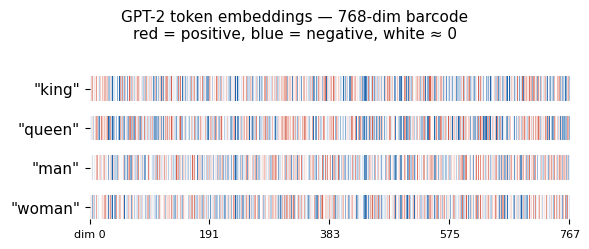

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_embedding_barcode(words, tokenizer, model, figsize_per_word=(6, 0.6)):
    embed_matrix = model.transformer.wte.weight.detach().numpy()

    vecs = []
    labels = []
    for word in words:
        ids = tokenizer.encode(' ' + word)
        vec = embed_matrix[ids].mean(axis=0)
        vecs.append(vec)
        labels.append(word)

    # Normalise across all vectors together so colours are comparable
    all_vals = np.concatenate(vecs)
    vmax = np.percentile(np.abs(all_vals), 98)  # robust max, ignores outliers

    fig, axes = plt.subplots(
        len(words), 1,
        figsize=(figsize_per_word[0], figsize_per_word[1] * len(words)),
        squeeze=False
    )

    cmap = mcolors.LinearSegmentedColormap.from_list(
        'rwb', ['#2166ac', '#ffffff', '#d6604d']  # blue → white → red
    )

    for ax, vec, label in zip(axes[:, 0], vecs, labels):
        # Reshape to (1, 768) so imshow treats it as a single-row image
        ax.imshow(
            vec[np.newaxis, :],
            aspect='auto',
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            interpolation='nearest'
        )
        ax.set_yticks([0])
        ax.set_yticklabels([f'"{label}"'], fontsize=11)
        ax.set_xticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Shared x-axis label and colorbar
    axes[-1, 0].set_xticks([0, 191, 383, 575, 767])
    axes[-1, 0].set_xticklabels(['dim 0', '191', '383', '575', '767'], fontsize=8)

    fig.suptitle('GPT-2 token embeddings — 768-dim barcode\n'
                 'red = positive, blue = negative, white ≈ 0',
                 fontsize=11, y=1.02)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])

    plt.tight_layout()
    plt.show()


plot_embedding_barcode(['king', 'queen', 'man', 'woman'],tokenizer, model)



**Question 5.**

Create "bar codes" for several words (they must be represented by single tokens). In the following code, you need to place each word in quotes, and the list of words in square brackets as shown. Do you notice any similar features across the bar codes, or does it look random?

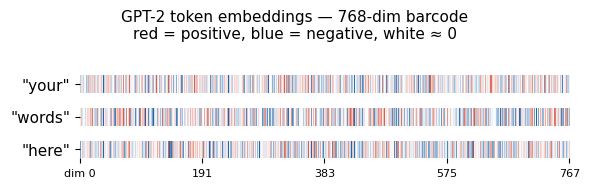

In [ ]:
plot_embedding_barcode(['your', 'words', 'here'],tokenizer, model)


**NOTE:**  The following Code Cell should already be loaded. It takes about 5 minutes to download the data, so no NOT press play on this code block if it is already loaded (look for the green checkmark by it).

In [ ]:
# Install gensim for Word2Vec (downloads ~1.6 GB pretrained vectors on first use)
!pip install -q gensim
import gensim.downloader as api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine as cosine_dist

print('Downloading Word2Vec pretrained vectors (Google News, 3M words)...')
print('This is ~1.6 GB — takes 2-5 minutes on Colab. Grab a coffee. ☕')
w2v = api.load('word2vec-google-news-300')
print(f'✅ Loaded! Vocabulary size: {len(w2v):,} words, vector size: {w2v.vector_size}d')

This is ~1.6 GB — takes 2-5 minutes on Colab. Grab a coffee. ☕
✅ Loaded! Vocabulary size: 3,000,000 words, vector size: 300d


We can see how close the two bar codes are to each other for two tokens. Mathematically, we calculate the distance in the embedding space (but don't worry about that). Run the following to see how close "dog" is to "cat" in the Word2Vec network. The black box is a bar, the wider it is, the more similar the words are.

In [ ]:
# ──  similarity between word pairs ──────────────────────────────
def similarity(w1, w2, model=w2v):
    """Cosine similarity between two words (1=identical, 0=unrelated, -1=opposite)."""
    return float(model.similarity(w1, w2))

def word_similarity(w1,w2,model=w2v):
    sim = similarity(w1, w2)
    bar = '█' * int(sim * 30)
    print(f'{w1}, {w2}   Similarity = {sim:>7.4f}  {bar}')

word_similarity('dog','cat')

**Question 6**

Run the similarity comparison on different pairs of words to see how similar they are. Write down some examples of what you find. BTW, you will get an error if the word is not a single token. Which make sense?  Which are surprising?


In [ ]:
word_similarity('dog','cat')

dog, cat   Similarity =  0.7609  ██████████████████████


**Analogies.**

One of the remarkable features of the embeddings that we have been studying is that different **directions** int this space correspond to different **concepts**.

For example if you subtract the following words: woman - man, the result is the concept of gender.

You can use this trait to create analogies using arithmetic: king − man + woman ≈ queen

The following code implements these analogies. Run it to see the result of several such analogies. The probability of the top three matches is given on the right.



In [ ]:
# ── Vector arithmetic: analogies ──────────────────────────────────────
def analogy(pos1, neg1, pos2, model, topn=5):
    """
    Solves: pos1 - neg1 + pos2 = ?
    Example: king - man + woman = queen
    """
    results = model.most_similar(positive=[pos1, pos2], negative=[neg1], topn=topn)
    return results


analogies = [
    ('king',    'man',     'woman',   'king − man + woman'),
    ('Paris',   'France',  'Germany', 'Paris − France + Germany'),
    ('walking', 'walk',    'swim',    'walking − walk + swim'),
    ('bigger',  'big',     'cold',    'bigger − big + cold'),
    ('uncle',   'man',     'woman',   'uncle − man + woman'),
    ('doctor',  'man',     'woman',   'doctor − man + woman'),
]

for pos1, neg1, pos2, label in analogies:
    try:
        results = analogy(pos1, neg1, pos2, w2v, topn=3)
        top = ', '.join(f'{w} ({s:.3f})' for w, s in results)
        print(f'  {label:35s}  →  {top}')
    except KeyError as e:
        print(f'  {label:35s}  →  word not in vocab: {e}')

print()
print('Note: the correct answer is usually #1 or #2 — but not always!')

  king − man + woman                   →  queen (0.712), monarch (0.619), princess (0.590)
  Paris − France + Germany             →  Berlin (0.764), Frankfurt (0.733), Dusseldorf (0.701)
  walking − walk + swim                →  swimming (0.825), swam (0.681), swims (0.654)
  bigger − big + cold                  →  colder (0.678), warmer (0.608), colder_temperatures (0.535)
  uncle − man + woman                  →  aunt (0.802), mother (0.777), niece (0.768)
  doctor − man + woman                 →  gynecologist (0.709), nurse (0.648), doctors (0.647)

Note: the correct answer is usually #1 or #2 — but not always!


**Question 7**

Now try it yourself. You can enter words to look for analogies. In math form it is A - B + C = ??. You can also think of it as "A is to B as ?? is to C". Try it out. See if you can find some examples that make sense. See if you can find examples that don't make sense. Can you think of reasons, the model might be making odd associations? Record your examples and your reflections.

In [ ]:
# ── 🎛️ Interactive analogy explorer ───────────────────────────────────
w1_widget = widgets.Text(value='king',   description='A:',  layout=widgets.Layout(width='180px'))
w2_widget = widgets.Text(value='man',    description='B:',  layout=widgets.Layout(width='180px'))
w3_widget = widgets.Text(value='woman',  description='C:',  layout=widgets.Layout(width='180px'))
btn_ana   = widgets.Button(description='▶ Compute A − B + C', button_style='primary',
                            layout=widgets.Layout(width='200px'))
out_ana   = widgets.Output()

header = widgets.HTML('<b>Analogy: A − B + C = ?</b><br><small>e.g. king − man + woman = queen</small>')

def run_analogy(b):
    with out_ana:
        clear_output(wait=True)
        A, B, C = w1_widget.value.strip(), w2_widget.value.strip(), w3_widget.value.strip()
        try:
            results = w2v.most_similar(positive=[A, C], negative=[B], topn=8)
            print(f'{A} − {B} + {C} = ?\n')
            print(f'{"Rank":>4}  {"Word":>15}  {"Cosine sim":>12}')
            print('-' * 36)
            for i, (word, score) in enumerate(results, 1):
                marker = ' ← answer?' if i == 1 else ''
                print(f'{i:>4}  {word:>15}  {score:>11.4f}{marker}')

            # Also show the vector arithmetic explicitly
            print('\nVector arithmetic:')
            v = w2v[A] - w2v[B] + w2v[C]
            print(f'  Result vector shape: {v.shape}')
            print(f'  First 8 dimensions:  {v[:8].round(3)}')
        except KeyError as e:
            print(f'Word not found in vocabulary: {e}')
            print('Try common English words in lowercase.')

btn_ana.on_click(run_analogy)
display(widgets.VBox([header,
                      widgets.HBox([w1_widget, w2_widget, w3_widget]),
                      btn_ana, out_ana]))

**Bonus Examples:**

The following are only if we have time. Feel free to explore them, but they are not part of this lab.

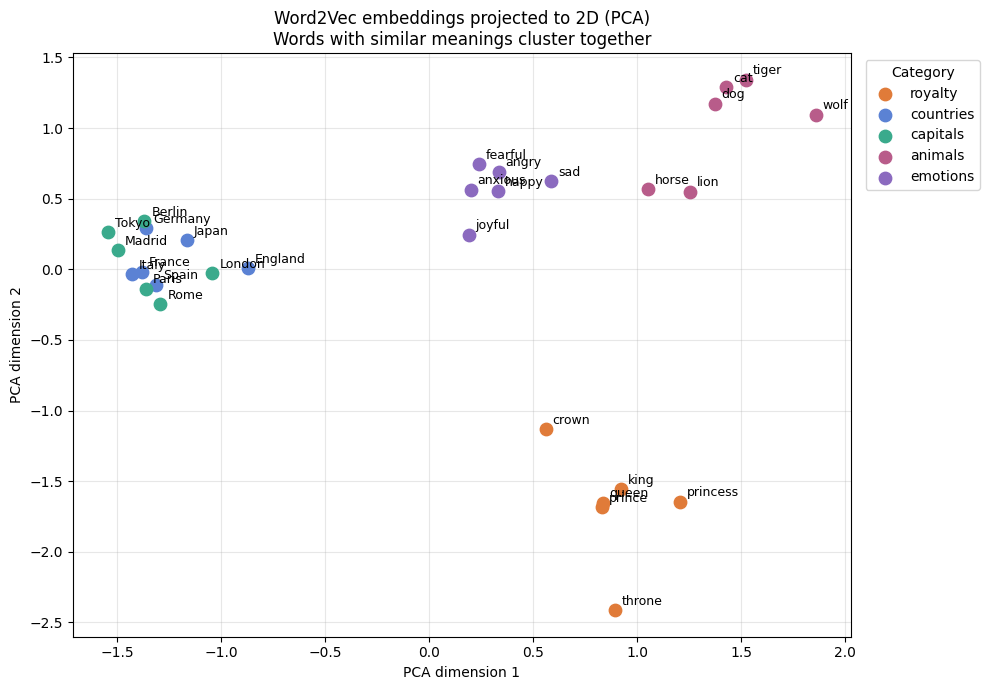

In [ ]:
# ── PCA visualisation: semantic clusters in 2D ────────────────────────
word_groups = {
    'royalty':   ['king', 'queen', 'prince', 'princess', 'throne', 'crown'],
    'countries': ['France', 'Germany', 'Italy', 'Spain', 'England', 'Japan'],
    'capitals':  ['Paris', 'Berlin', 'Rome', 'Madrid', 'London', 'Tokyo'],
    'animals':   ['dog', 'cat', 'horse', 'lion', 'tiger', 'wolf'],
    'emotions':  ['happy', 'sad', 'angry', 'fearful', 'joyful', 'anxious'],
}

colors_map = {
    'royalty': '#e07b39',
    'countries': '#5b82d4',
    'capitals': '#3aaa8c',
    'animals': '#b85c8a',
    'emotions': '#8b6abf',
}

words_flat, vecs, group_labels = [], [], []
for group, words in word_groups.items():
    for w in words:
        if w in w2v:
            words_flat.append(w)
            vecs.append(w2v[w])
            group_labels.append(group)

vecs_2d = PCA(n_components=2).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for group in word_groups:
    mask = [i for i, g in enumerate(group_labels) if g == group]
    ax.scatter(vecs_2d[mask, 0], vecs_2d[mask, 1],
               c=colors_map[group], label=group, s=80, zorder=3)
    for i in mask:
        ax.annotate(words_flat[i],
                    (vecs_2d[i, 0], vecs_2d[i, 1]),
                    textcoords='offset points', xytext=(5, 4), fontsize=9)

ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Word2Vec embeddings projected to 2D (PCA)\nWords with similar meanings cluster together')
ax.set_xlabel('PCA dimension 1')
ax.set_ylabel('PCA dimension 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

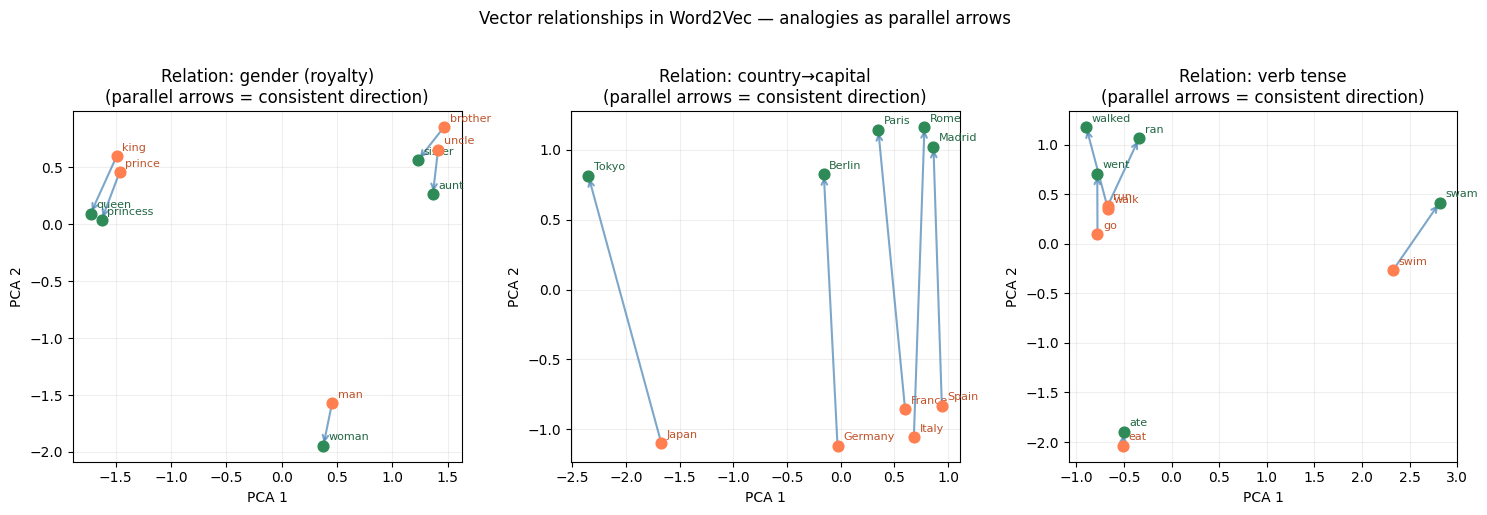

In [ ]:
# ── Visualise analogy as a vector arrow ───────────────────────────────
# Shows that king→queen and man→woman are nearly parallel vectors

analogy_words = {
    'gender (royalty)': [('man', 'woman'), ('king', 'queen'), ('prince', 'princess'),
                          ('uncle', 'aunt'), ('brother', 'sister')],
    'country→capital': [('France', 'Paris'), ('Germany', 'Berlin'),
                          ('Italy', 'Rome'), ('Spain', 'Madrid'), ('Japan', 'Tokyo')],
    'verb tense':       [('walk', 'walked'), ('run', 'ran'),
                          ('swim', 'swam'), ('eat', 'ate'), ('go', 'went')],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (relation, pairs_r) in zip(axes, analogy_words.items()):
    all_words = [w for pair in pairs_r for w in pair]
    vecs_r = [w2v[w] for w in all_words if w in w2v]
    words_r = [w for w in all_words if w in w2v]

    coords = PCA(n_components=2).fit_transform(vecs_r)

    # Draw arrows from word1 → word2 in each pair
    idx = {w: i for i, w in enumerate(words_r)}
    for w1, w2 in pairs_r:
        if w1 in idx and w2 in idx:
            i1, i2 = idx[w1], idx[w2]
            ax.annotate('', xy=coords[i2], xytext=coords[i1],
                        arrowprops=dict(arrowstyle='->', color='steelblue',
                                        lw=1.5, alpha=0.7))
            ax.scatter(*coords[i1], color='coral',   s=60, zorder=4)
            ax.scatter(*coords[i2], color='seagreen', s=60, zorder=4)
            ax.annotate(w1, coords[i1], xytext=(4, 4),
                        textcoords='offset points', fontsize=8, color='#c0522a')
            ax.annotate(w2, coords[i2], xytext=(4, 4),
                        textcoords='offset points', fontsize=8, color='#226644')

    ax.set_title(f'Relation: {relation}\n(parallel arrows = consistent direction)')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('Vector relationships in Word2Vec — analogies as parallel arrows', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── GPT-2 token embeddings: how do they compare? ──────────────────────
# GPT-2's embedding matrix maps each token ID to a 768-dim vector.
# These are trained for next-token prediction, not semantic similarity.

gpt2_embed = model.transformer.wte.weight.detach().numpy()  # shape: (50257, 768)
print(f'GPT-2 embedding matrix shape: {gpt2_embed.shape}')
print(f'  {gpt2_embed.shape[0]:,} tokens × {gpt2_embed.shape[1]} dimensions\n')


def gpt2_vec(word, tokenizer, embed_matrix):
    """Get GPT-2 embedding for a single word (uses the first token if it splits)."""
    # Try with a leading space (GPT-2 tokenizes ' king' not 'king' for mid-sentence words)
    ids = tokenizer.encode(' ' + word)
    if len(ids) == 1:
        return embed_matrix[ids[0]]
    # Word splits into multiple tokens — average them
    return embed_matrix[ids].mean(axis=0)


def gpt2_cosine(w1, w2):
    v1 = gpt2_vec(w1, tokenizer, gpt2_embed)
    v2 = gpt2_vec(w2, tokenizer, gpt2_embed)
    return 1 - cosine_dist(v1, v2)


print('Cosine similarities — GPT-2 token embeddings:')
print(f'{"Word 1":>12}  {"Word 2":>12}  {"GPT-2":>8}  {"Word2Vec":>10}')
print('-' * 48)
test_pairs = [
    ('king',  'queen'),
    ('dog',   'cat'),
    ('happy', 'joyful'),
    ('happy', 'sad'),
    ('dog',   'ocean'),
]
for w1, w2 in test_pairs:
    g = gpt2_cosine(w1, w2)
    try:
        wv = w2v.similarity(w1, w2)
    except:
        wv = float('nan')
    print(f'{w1:>12}  {w2:>12}  {g:>8.4f}  {wv:>10.4f}')

GPT-2 embedding matrix shape: (50257, 768)
  50,257 tokens × 768 dimensions

Cosine similarities — GPT-2 token embeddings:
      Word 1        Word 2     GPT-2    Word2Vec
------------------------------------------------
        king         queen    0.6573      0.6511
         dog           cat    0.5498      0.7609
       happy        joyful    0.5887      0.4238
       happy           sad    0.5497      0.5355
         dog         ocean    0.2387      0.1119


In [ ]:
# ── Analogy arithmetic in GPT-2 embedding space ───────────────────────
# Does king - man + woman ≈ queen in GPT-2's space too?

def gpt2_analogy(pos1, neg1, pos2, topn=5):
    """
    pos1 - neg1 + pos2 = ?
    Searches by cosine similarity over the full GPT-2 vocabulary.
    """
    v = (gpt2_vec(pos1, tokenizer, gpt2_embed)
         - gpt2_vec(neg1, tokenizer, gpt2_embed)
         + gpt2_vec(pos2, tokenizer, gpt2_embed))

    # Cosine similarity between v and every token in the vocab
    norms = np.linalg.norm(gpt2_embed, axis=1, keepdims=True) + 1e-9
    sims  = gpt2_embed @ v / (norms.squeeze() * np.linalg.norm(v))

    # Exclude the input words themselves
    exclude = set()
    for w in [pos1, neg1, pos2]:
        for tid in tokenizer.encode(' ' + w):
            exclude.add(tid)

    top_idx = np.argsort(sims)[::-1]
    results = []
    for i in top_idx:
        if i not in exclude:
            results.append((tokenizer.decode([i]).strip(), float(sims[i])))
        if len(results) >= topn:
            break
    return results


print('Analogy results — GPT-2 token embeddings vs Word2Vec\n')
print(f'{"Analogy":35s}  {"GPT-2 top-3":40s}  Word2Vec top-3')
print('-' * 115)

test_analogies = [
    ('king',    'man',     'woman'),
    ('Paris',   'France',  'Germany'),
    ('bigger',  'big',     'cold'),
    ('walking', 'walk',    'swim'),
]

for pos1, neg1, pos2 in test_analogies:
    label = f'{pos1} − {neg1} + {pos2}'
    g_res = gpt2_analogy(pos1, neg1, pos2, topn=3)
    g_str = ', '.join(f'{w}({s:.2f})' for w, s in g_res)
    try:
        w_res = w2v.most_similar(positive=[pos1, pos2], negative=[neg1], topn=3)
        w_str = ', '.join(f'{w}({s:.2f})' for w, s in w_res)
    except:
        w_str = 'n/a'
    print(f'{label:35s}  {g_str:40s}  {w_str}')

print('\nGPT-2 often finds related words, but the geometry is less precise.')

Analogy results — GPT-2 token embeddings vs Word2Vec

Analogy                              GPT-2 top-3                               Word2Vec top-3
-------------------------------------------------------------------------------------------------------------------
king − man + woman                   queen(0.71), princess(0.60), Queen(0.60)  queen(0.71), monarch(0.62), princess(0.59)
Paris − France + Germany             Berlin(0.67), Paris(0.61), Munich(0.60)   Berlin(0.76), Frankfurt(0.73), Dusseldorf(0.70)
bigger − big + cold                  colder(0.71), cold(0.63), Cold(0.60)      colder(0.68), warmer(0.61), colder_temperatures(0.53)
walking − walk + swim                swimming(0.73), Swim(0.61), bathing(0.56)  swimming(0.82), swam(0.68), swims(0.65)

GPT-2 often finds related words, but the geometry is less precise.


Running t-SNE...


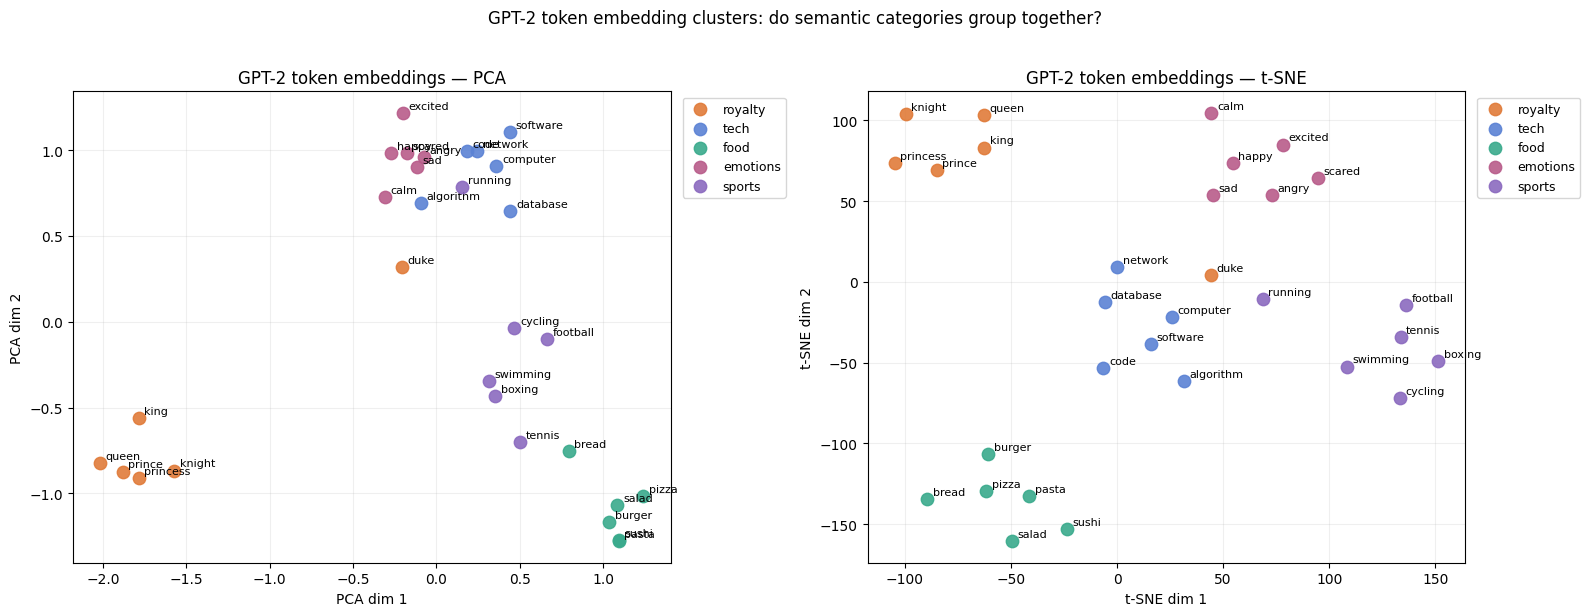

In [ ]:
# ── t-SNE: nonlinear 2D projection of GPT-2 embeddings ────────────────
# t-SNE better preserves local neighbourhood structure than PCA

tsne_groups = {
    'royalty':   ['king', 'queen', 'prince', 'princess', 'duke', 'knight'],
    'tech':      ['computer', 'software', 'algorithm', 'database', 'network', 'code'],
    'food':      ['pizza', 'burger', 'sushi', 'pasta', 'bread', 'salad'],
    'emotions':  ['happy', 'sad', 'angry', 'scared', 'excited', 'calm'],
    'sports':    ['football', 'tennis', 'swimming', 'cycling', 'running', 'boxing'],
}

colors_tsne = ['#e07b39', '#5b82d4', '#3aaa8c', '#b85c8a', '#8b6abf']

words_t, vecs_t, labels_t = [], [], []
for group, words in tsne_groups.items():
    for w in words:
        words_t.append(w)
        vecs_t.append(gpt2_vec(w, tokenizer, gpt2_embed))
        labels_t.append(group)

# Run t-SNE
print('Running t-SNE...')
#tsne_2d = TSNE(n_components=2, perplexity=8, random_state=42,
#               n_iter=1000).fit_transform(np.array(vecs_t))
tsne_2d = TSNE(n_components=2, perplexity=8, random_state=42).fit_transform(np.array(vecs_t))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
group_list = list(tsne_groups.keys())

for ax, (method, coords) in zip(
    axes,
    [('PCA', PCA(n_components=2).fit_transform(np.array(vecs_t))),
     ('t-SNE', tsne_2d)]
):
    for group, color in zip(group_list, colors_tsne):
        mask = [i for i, g in enumerate(labels_t) if g == group]
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=color, label=group, s=80, zorder=3, alpha=0.9)
        for i in mask:
            ax.annotate(words_t[i], (coords[i, 0], coords[i, 1]),
                        textcoords='offset points', xytext=(4, 3), fontsize=8)
    ax.set_title(f'GPT-2 token embeddings — {method}')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.set_xlabel(f'{method} dim 1')
    ax.set_ylabel(f'{method} dim 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('GPT-2 token embedding clusters: do semantic categories group together?',
             y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── 🎛️ Interactive: nearest neighbours in GPT-2 embedding space ───────
query_widget = widgets.Text(value='ocean', description='Word:',
                             layout=widgets.Layout(width='220px'))
model_widget = widgets.ToggleButtons(options=['GPT-2', 'Word2Vec'],
                                      description='Model:',
                                      style={'description_width': '50px'})
n_widget  = widgets.IntSlider(value=10, min=3, max=25, step=1,
                               description='Top N:', style={'description_width': '60px'},
                               layout=widgets.Layout(width='300px'))
btn_nn    = widgets.Button(description='▶ Find neighbours', button_style='primary',
                            layout=widgets.Layout(width='180px'))
out_nn    = widgets.Output()

def find_neighbours(b):
    with out_nn:
        clear_output(wait=True)
        word  = query_widget.value.strip()
        N     = n_widget.value
        use   = model_widget.value

        if use == 'Word2Vec':
            try:
                results = w2v.most_similar(word, topn=N)
                print(f'Nearest neighbours to "{word}" in Word2Vec space:\n')
                for i, (w, s) in enumerate(results, 1):
                    bar = '█' * int(s * 40)
                    print(f'{i:>3}. {w:>18}  {s:.4f}  {bar}')
            except KeyError:
                print(f'"{word}" not found in Word2Vec vocabulary.')
        else:
            v    = gpt2_vec(word, tokenizer, gpt2_embed)
            norms = np.linalg.norm(gpt2_embed, axis=1) + 1e-9
            sims  = gpt2_embed @ v / (norms * np.linalg.norm(v))
            top_i = np.argsort(sims)[::-1][1:N+1]   # skip token 0 (=itself usually)
            print(f'Nearest neighbours to "{word}" in GPT-2 embedding space:\n')
            for i, idx in enumerate(top_i, 1):
                w_str = repr(tokenizer.decode([idx]).strip())
                s     = sims[idx]
                bar   = '█' * int(s * 40)
                print(f'{i:>3}. {w_str:>20}  {s:.4f}  {bar}')

btn_nn.on_click(find_neighbours)
display(widgets.VBox([
    widgets.HTML('<b>Nearest neighbour explorer</b>'),
    widgets.HBox([query_widget, model_widget, n_widget]),
    btn_nn, out_nn
]))